<a href="https://colab.research.google.com/github/iqiirascal-lgtm/DAA/blob/main/DAA_M14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Kasus fraud analytics
# import library yang akan digunakan

import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# Buat Array verticesdan edges yang akan disusun

vertices = range(1,10)
edges = [(7,2),(2,3),(7,4),(4,5),(7,3),(7,5),(1,6),(1,7),(2,8),(2,9)]

In [ ]:
# Susun vertices menjadi nodes dan edges dalam grafik G

G = nx.Graph()

In [ ]:
G.add_nodes_from(vertices)
G.add_edges_from(edges)
pos=nx.spring_layout(G)

{1: Text(-0.14171162133880347, 0.6086064090368134, '1 NF'),
 2: Text(-0.07985938174898675, -0.4446572908064007, '2 F'),
 3: Text(-0.16925576520183772, -0.1434632284819016, '3 NF'),
 4: Text(0.49975650194403193, 0.1265238146297045, '4 NF'),
 5: Text(0.41388672137245064, 0.35929383113114266, '5 F'),
 6: Text(-0.30388410883719563, 1.0, '6 F'),
 7: Text(0.08260488716804901, 0.11173397867219752, '7 F'),
 8: Text(0.08214983063754834, -0.8541261780579628, '8 NF'),
 9: Text(-0.38368706399525665, -0.7639113361235934, '9 NF')}

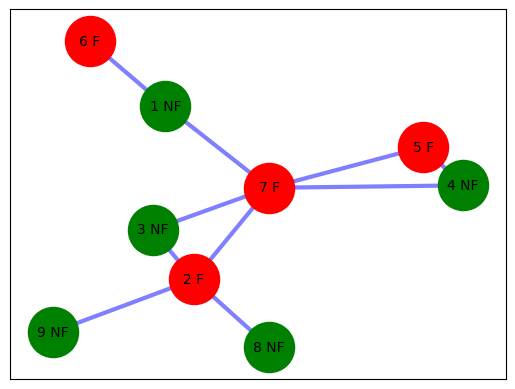

In [ ]:
#Gambar Nodes dan Edges beserta labelnya menggunakan NetworkX. NF berwarna hijau, sedangkan F berwarna merah.
nx.draw_networkx_nodes(G, pos, nodelist=[1,4,3,8,9], node_color='g', node_size=1300)
nx.draw_networkx_nodes(G, pos, nodelist=[2,5,6,7], node_color='r', node_size=1300)
nx.draw_networkx_edges(G, pos, edges, width=3, alpha=0.5, edge_color='b')
labels={}
labels[1]=r'1 NF'
labels[2]=r'2 F'
labels[3]=r'3 NF'
labels[4]=r'4 NF'
labels[5]=r'5 F'
labels[6]=r'6 F'
labels[7]=r'7 F'
labels[8]=r'8 NF'
labels[9]=r'9 NF'

nx.draw_networkx_labels(G, pos,labels, font_size=10)

{1: Text(-0.18181648388080898, 0.6064139812202352, '1 NF (DOS=2)'),
 2: Text(-0.11557777882608568, -0.4592618313670062, '2 F (DOS=4)'),
 3: Text(0.14871865785757513, -0.2683218479820508, '3 NF (DOS=2)'),
 4: Text(0.4405695729744124, 0.432100557719207, '4 NF (DOS=2)'),
 5: Text(0.5748557622911976, 0.19927487073738548, '5 F (DOS=2)'),
 6: Text(-0.40509079842080675, 1.0, '6 F (DOS=1)'),
 7: Text(0.12257982858195121, 0.11440009884608093, '7 F (DOS=5)'),
 8: Text(-0.06328519759077317, -0.9305658607032813, '8 NF (DOS=1)'),
 9: Text(-0.520953562986662, -0.6940399684705711, '9 NF (DOS=1)')}

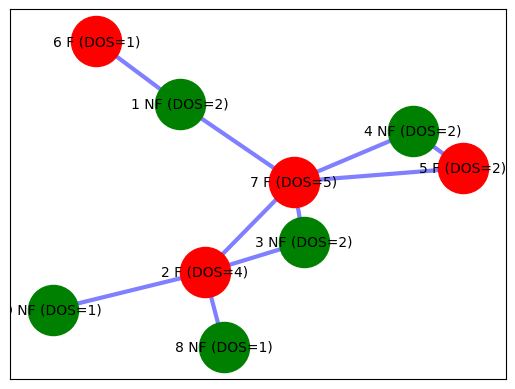

In [ ]:
# NEIGHBOR & DOS VALUES

pos = nx.spring_layout(G, seed=42)

#Gambar Nodes dan Edges beserta labelnya menggunakan NetworkX. NF berwarna hijau, sedangkan F berwarna merah.
nx.draw_networkx_nodes(G, pos, nodelist=[1,4,3,8,9], node_color='g', node_size=1300)
nx.draw_networkx_nodes(G, pos, nodelist=[2,5,6,7], node_color='r', node_size=1300)
nx.draw_networkx_edges(G, pos, edges, width=3, alpha=0.5, edge_color='b')

labels={}
labels[1]=r'1 NF'
labels[2]=r'2 F'
labels[3]=r'3 NF'
labels[4]=r'4 NF'
labels[5]=r'5 F'
labels[6]=r'6 F'
labels[7]=r'7 F'
labels[8]=r'8 NF'
labels[9]=r'9 NF'

# Calculate DOS for each node
def calculate_dos(node):
    dos = 0
    for neighbor in G.neighbors(node):
        if labels[neighbor] != labels[node]:
            dos += 1
    return dos

dos_values = {node: calculate_dos(node) for node in G.nodes()}
labels = {node: f"{node} ({dos_values[node]})" for node in G.nodes()}
nx.draw_networkx_labels(G, pos, dos_labels, font_size=10)


In [ ]:
# DOS NORMALIZED

import networkx as nx
import matplotlib.pyplot as plt

# Membuat graph (jaringan sosial)
G = nx.Graph()

# Menambahkan vertices dan edges
vertices = range(1, 10)
edges = [(7, 2), (2, 3), (7, 4), (4, 5), (7, 3), (7, 5), (1, 6), (1, 7), (2, 8), (2, 9)]
G.add_nodes_from(vertices)
G.add_edges_from(edges)

# Menghitung derajat setiap node
degree_values = dict(G.degree())

# DOS values (derajat tanpa normalisasi)
dos_values = {node: degree for node, degree in degree_values.items()}

# Menampilkan DOS values
print("Dos values:")
for node, dos in dos_values.items():
    print(f"{node}: {dos}")

# Normalisasi nilai derajat ke dalam rentang 0-9
max_degree = max(degree_values.values())

# Menghitung DOS values (derajat yang dinormalisasi)
normalized_dos_values = {node: round((degree / max_degree) * 9, 2) for node, degree in degree_values.items()}

# Menampilkan DOS values (derajat yang dinormalisasi)
print("\nNormalized DOS values:")
for node, normalized_dos in normalized_dos_values.items():
    print(f"{node}: {normalized_dos}")


Dos values:
1: 2
2: 4
3: 2
4: 2
5: 2
6: 1
7: 5
8: 1
9: 1

Normalized DOS values:
1: 3.6
2: 7.2
3: 3.6
4: 3.6
5: 3.6
6: 1.8
7: 9.0
8: 1.8
9: 1.8


In [ ]:
import networkx as nx

# Membuat graph Latihan 1
G1 = nx.Graph()

# Daftar edges sesuai gambar
edges1 = [
    (1, 7), (2, 7), (2, 3), (3, 6), (3, 4),
    (6, 7), (6, 5), (7, 8), (7, 9), (7, 10), (8, 9)
]

# Menambahkan edges ke graph
G1.add_edges_from(edges1)

# Hitung degree (DOS)
degree_L1 = dict(G1.degree())

print("DOS Values:")
for node, d in degree_L1.items():
    print(f"{node}: {d}")

# Normalisasi derajat ke skala 0–9
max_degree_L1 = max(degree_L1.values())
normalized_L1 = {node: round((d / max_degree_L1) * 9, 2) for node, d in degree_L1.items()}

print("\nNormalized DOS:")
for node, nd in normalized_L1.items():
    print(f"{node}: {nd}")


DOS Values:
1: 1
7: 6
2: 2
3: 3
6: 3
4: 1
5: 1
8: 2
9: 2
10: 1

Normalized DOS:
1: 1.5
7: 9.0
2: 3.0
3: 4.5
6: 4.5
4: 1.5
5: 1.5
8: 3.0
9: 3.0
10: 1.5


In [ ]:
import networkx as nx

# Membuat graph Latihan 2
G2 = nx.Graph()

# Daftar edges sesuai gambar
edges2 = [
    (1, 3), (2, 3), (2, 12), (12, 13), (12, 11),
    (3, 11), (3, 10), (3, 4), (4, 5), (4, 7),
    (5, 7), (5, 8), (5, 9),
    (6, 4), (6, 5), (6, 9)
]

# Menambahkan edges
G2.add_edges_from(edges2)

# Hitung degree (DOS)
degree_L2 = dict(G2.degree())

print("DOS Values:")
for node, d in degree_L2.items():
    print(f"{node}: {d}")

# Normalisasi derajat ke skala 0–9
max_degree_L2 = max(degree_L2.values())
normalized_L2 = {node: round((d / max_degree_L2) * 9, 2) for node, d in degree_L2.items()}

print("\nNormalized DOS):")
for node, nd in normalized_L2.items():
    print(f"{node}: {nd}")


DOS Values:
1: 1
3: 5
2: 2
12: 3
13: 1
11: 2
10: 1
4: 4
5: 5
7: 2
8: 1
9: 2
6: 3

Normalized DOS):
1: 1.8
3: 9.0
2: 3.6
12: 5.4
13: 1.8
11: 3.6
10: 1.8
4: 7.2
5: 9.0
7: 3.6
8: 1.8
9: 3.6
6: 5.4
